# GDL - Midterm n.1
**Student ID: 656365** (Your student "matricola" goes here)

**Submission ID: 051** (The ID from the sheet circulated in classroom goes here)

In the first midterm assignment, you are required to implement a Gaussian Mixture Model (GMM) and the Expectation-Maximization (EM) algorithm. You are allowed to use `numpy` and other non-machine learning libraries, e.g., `pandas`, `matplotlib`.

**Assumptions.** To ease the implementation, we assume, for each Gaussian distribution in the mixture $\mathcal{N}(\mu_k, \Sigma_k)$, that the *covariance matrix is diagonal*. Furthermore, keep in mind that a good implementation of the EM algorithm provides monotonically increasing log-likelihood, *but* can get stuck in local minima; initialization strategies are fundamental (random? sample points? k-means++?).

**Hyperparameter $k$.** When using a GMM, you should ask yourself: *how many mixtures will be in the data?* You can *maximize* the Bayesian Information Criterion (BIC) to select the number of categories $k$ on your training set. Formally,
$$
\text{BIC}
=
\log P(X\mid \theta) - \frac{|\theta|}{2}\log n,
$$
where $n$ is the number of samples in the training set, $\theta=\{\pi,\mu,\sigma\}$ the parameters of the GMM and $|\theta|$ the number of parameters, i.e., the sum of the number of parameters in $\pi$, $\mu$, and $\sigma$ (*hint*: it also depends on the dimensionality of data $d$!).

**Summary.** Overall, you are required to:
1.  **Implement the GMM class**. Fill the `log_likelihood(samples)`.
2. **Implement the EM algorithm**. Fill the `fit(samples)` method to fit the parameters of a GMM.
3. **Implement the BIC score**. Fill the `bic(samples)` method to perform model selection.
4. **Run training and evaluation**. Select the best scoring model using BIC (Bayesian Information Criterion) for values of $k=\{1,\ldots,6\}$.

**Evaluation.** Your solution will be tested against an hidden test set. For your learning experience, we require you to refrain from using LLM generated code. Violations will be flagged and invalidate the midterm. **Do not alter Sections 3 and 4 of the notebook.**

### 1. Libraries

In [1]:
import random

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def seed_everything(seed: int):
    random.seed(seed)
    np.random.seed(seed)

print("Libraries imported successfully.")

Libraries imported successfully.


### 2. Gaussian Mixture Model (GMM)

Feel free to play around the implementation. **For evaluation purposes**, the class **must** expose the following attributes and methods:
- `_pi: np.ndarray`
- `_mu: np.ndarray`
- `_sigma: np.ndarray`
- `fit(samples: np.ndarray)`
- `bic(samples: np.ndarray) -> np.ndarray`
- `log_likelihood(samples: np.ndarray) -> np.ndarray`

In [ ]:
def N(x: np.ndarray, mu: np.ndarray, sigma: np.ndarray):
    """Function to obtain the probability of having x in the normal gaussian expressed by multidimensional N(mu, sigma)"""
    d = x.shape[0]
    denom = 1/np.sqrt((2 * np.pi)**d * np.prod(sigma))
    exp = np.exp(-1/2 * np.sum((x - mu)**2/sigma))
    return denom * exp

In [ ]:
def compute_distance(p1, p2):
    return np.sqrt(np.sum((p1 - p2)**2))

def init_mu(samples: np.ndarray, k: int):
    """kmeans++ method to initialize the mu array"""
    mu_s = []
    mu_s.append(samples[np.random.randint(samples.shape[0])]) # take a random mu
    for _ in range(k-1):
        distances = []
        for x in samples:
            min_distance = min([compute_distance(x, mu) for mu in mu_s]) # take the closest mu
            distances.append(min_distance)
        mu_s.append(samples[np.argmax(distances)])
    return np.array(mu_s)

In [ ]:
class GaussianMixtureModel:
    def __init__(self, n_categories: int, n_features: int, method: str="random"): # method represents the way of initializing the parameters
        self.n_categories = n_categories

        # Choose a smart initialization strategy for the parameters!
        # weights (pi), means (mu), covariances (sigma)
        # NOTE: for the covariance, you can store only the diagonal
        self._pi = None # Shape: (n_categories,)
        self._mu = None   # Shape: (n_categories, n_features)
        self._sigma = None # Shape: (n_categories, n_features)
        if method == "random":
            self._pi = np.random.rand(n_categories,)
            self._pi = self._pi/np.sum(self._pi) # keep the sum-to-1 constraint
            self._mu = np.random.rand(n_categories, n_features)
            self._sigma = np.random.rand(n_categories, n_features)

    def log_likelihood(self, samples: np.ndarray) -> np.ndarray:
        """Computes logP(X|θ)"""
        res = np.ndarray(samples.shape[0])
        res = 0.0
        for i in range(samples.shape[0]):
            likelihood = 0.0
            for m in range(self.n_categories):
                # log likelihood: pi[m] * N(x | mu[m], sigma[m][m])
                p_x_in_gaussian_m = N(samples[i], self._mu[m], self._sigma[m]) # probability of x in the gaussian m
                likelihood += self._pi[m] * p_x_in_gaussian_m
            res += np.log(likelihood + 1e-10)
        return res

    def fit(self, samples: np.ndarray):
        """Fits the GMM parameters using the EM algorithm."""
        curr_ll = None
        next_ll = None
        iter = 0
        self._mu = init_mu(samples, self.n_categories)
        while (curr_ll is None or next_ll is None) or (abs(curr_ll - next_ll) > 1e-6): # until convergence
            # expectation phase
            posteriors = np.ndarray((samples.shape[0], self.n_categories))
            for i, x in enumerate(samples):
                for k in range(self.n_categories):
                    # get the posterior using the formula r
                    posteriors[i][k] = (self._pi[k]*N(x, self._mu[k], self._sigma[k]))/(np.sum([self._pi[m]*N(x, self._mu[m], self._sigma[m]) for m in range(self.n_categories)]) + 1e-10)
            
            # maximization term
            curr_ll = self.log_likelihood(samples)
            sum_N = np.ndarray(self.n_categories)
            for m in range(self.n_categories):
                sum_N[m] = np.sum(posteriors[:, m])
            for m in range(self.n_categories):
                self._pi[m] = sum_N[m]/samples.shape[0] # update pi
                self._mu[m] = (np.sum([(posteriors[i][m]*samples[i]) for i in range(samples.shape[0])], axis=0))/(sum_N[m] + 1e-10) # update mu
                self._sigma[m] = np.sum([posteriors[i][m]*((samples[i]-self._mu[m])**2) for i in range(samples.shape[0])], axis=0)/(sum_N[m] + 1e-10) # update sigma
                # covariance regularization (+\lambda I)
                self._sigma[m] = self._sigma[m] + 1e-6
            next_ll = self.log_likelihood(samples)
            iter += 1


    def bic(self, samples: np.ndarray) -> np.ndarray:
        """Computes the BIC score."""
        n_params = self._pi.shape[0]-1 + self._mu.shape[0]*self._mu.shape[1] + self._sigma.shape[0]*self._sigma.shape[1] # self._pi.shape[0]-1 for the sum-to-one constraint, one has to have the fixed value
        second_term = n_params/2 * np.log(samples.shape[0])
        return self.log_likelihood(samples)-second_term

### 3. Training

Trains the model for increasing number of categories and selects the best scoring one in terms of BIC score.

In [5]:
# load training set
train_df = pd.read_csv('train.csv')
print(f"train.csv loaded successfully. n={train_df.shape[0]}, d={train_df.shape[1]}")

# model selection using bayesian information score
seed_everything(9951)
candidate_categories = range(1, 7)
max_bic, best_k, best_gmm = -np.inf, None, None
bics = np.ndarray(6)
lls = np.ndarray(6)
gmms = []
for k in candidate_categories:
    gmm = GaussianMixtureModel(n_categories=k, n_features=train_df.shape[1])
    gmm.fit(train_df.values)
    gmms.append(gmm)
    ll = gmm.log_likelihood(train_df.values)
    lls[k-1] = ll
    bic_score = gmm.bic(train_df.values)
    bics[k-1] = bic_score
    print(f"k={k}\tBIC={bic_score:.4f}\tlogP(X|θ)={ll:.4f}")
    if bic_score > max_bic:
        max_bic = bic_score
        best_k = k
        best_gmm = gmm

# print training info
print()
print("Best model")
print(f"k:\t\t{best_k}")
print(f"BIC:\t\t{max_bic:.4f}")
print(f"logP(X|θ):\t{best_gmm.log_likelihood(train_df.values):.4f}")

train.csv loaded successfully. n=800, d=5
k=1	BIC=-8323.5194	logP(X|θ)=-8286.7541
k=2	BIC=-8055.3839	logP(X|θ)=-7981.8532
k=3	BIC=-8083.1382	logP(X|θ)=-7972.8421
k=4	BIC=-7950.2123	logP(X|θ)=-7803.1509
k=5	BIC=-7869.9277	logP(X|θ)=-7686.1009
k=6	BIC=-7928.3907	logP(X|θ)=-7707.7985

Best model
k:		5
BIC:		-7869.9277
logP(X|θ):	-7686.1009


### 4. Evaluation

To check if you did not break the API, you can use the training file to run the tests.

This is not meaningful for the evaluation of your model, as the true test set is hidden.

In [6]:
# If test.csv does not exist copy train into test
!test -f test.csv || cp train.csv test.csv

In [7]:
# load hidden test set ☠️
test_df = pd.read_csv('test.csv')
print(f"test.csv loaded successfully. n={test_df.shape[0]}, d={test_df.shape[1]}")

# print log-likelihood
test_log_likelihood = best_gmm.log_likelihood(test_df.values)
print(f"Log-likelihood of test data: {test_log_likelihood:.4f}")

# print parameters
print(f"k: {best_gmm.n_categories}")
print()
for cat_id in range(best_gmm.n_categories):
  print(f"π[{cat_id}]:", best_gmm._pi[cat_id])
  print(f"μ[{cat_id}]:", best_gmm._mu[cat_id])
  print(f"σ[{cat_id}]:", best_gmm._sigma[cat_id])
  print()

test.csv loaded successfully. n=800, d=5
Log-likelihood of test data: -7686.1009
k: 5

π[0]: 0.4360423184654201
μ[0]: [-2.01693892  0.56048207 -2.33702015 -0.50668914 -0.11599775]
σ[0]: [2.56411281 2.24921574 1.23195734 1.64748992 2.80667881]

π[1]: 0.3213930953490764
μ[1]: [-2.75498371 -0.58395807 -0.46562479  2.07362776 -3.81146566]
σ[1]: [1.53905128 3.16019198 1.01811168 2.1381661  1.56795252]

π[2]: 0.12054501505422623
μ[2]: [-2.94960016 -1.75890641  0.81729967  2.463576   -0.0983883 ]
σ[2]: [2.33271542 2.57572267 0.76136848 2.37325995 0.66057339]

π[3]: 0.00125
μ[3]: [-5.41100216  1.06893814  2.5045607  -1.86530157 -4.49866204]
σ[3]: [1.e-06 1.e-06 1.e-06 1.e-06 1.e-06]

π[4]: 0.12076125252328454
μ[4]: [ 1.87861921  2.3961489  -0.1966717   0.26448851 -0.80266838]
σ[4]: [0.49307821 1.76637326 1.39043991 1.55274941 3.25150405]



### Plotting data and gaussians over the different values of $k$

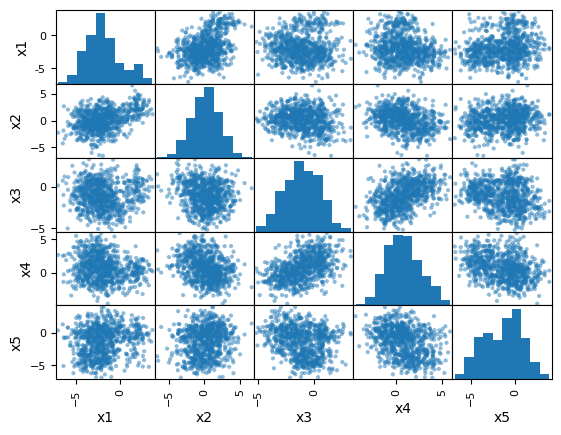

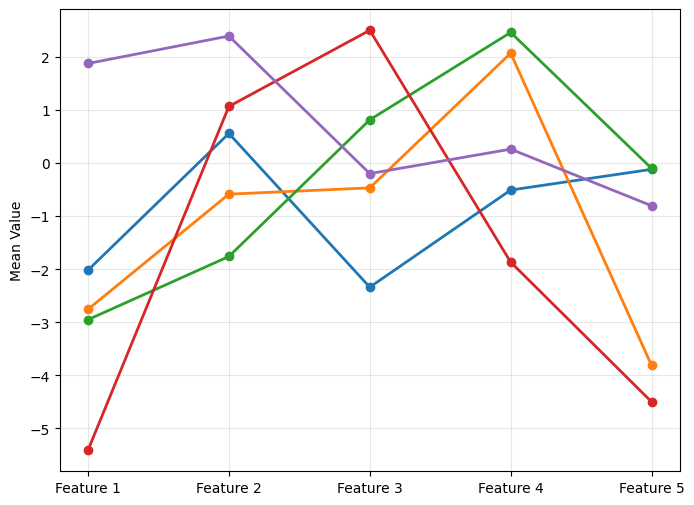

In [13]:
from matplotlib.patches import Ellipse


pd.plotting.scatter_matrix(train_df) # plot the dataset in different combinations of variables

plt.figure(figsize=(8, 6))
features = [f"Feature {i+1}" for i in range(train_df.shape[1])]
for m in range(best_gmm.n_categories):
    plt.plot(features, best_gmm._mu[m], marker="o", linewidth=2, label=f"Cluster {m} (Weight: {best_gmm._pi[m]:.2f})")
plt.ylabel("Mean Value")
plt.grid(True, alpha=0.3)
plt.show()

### Plotting of metrics over different values of $k$ (clusters)

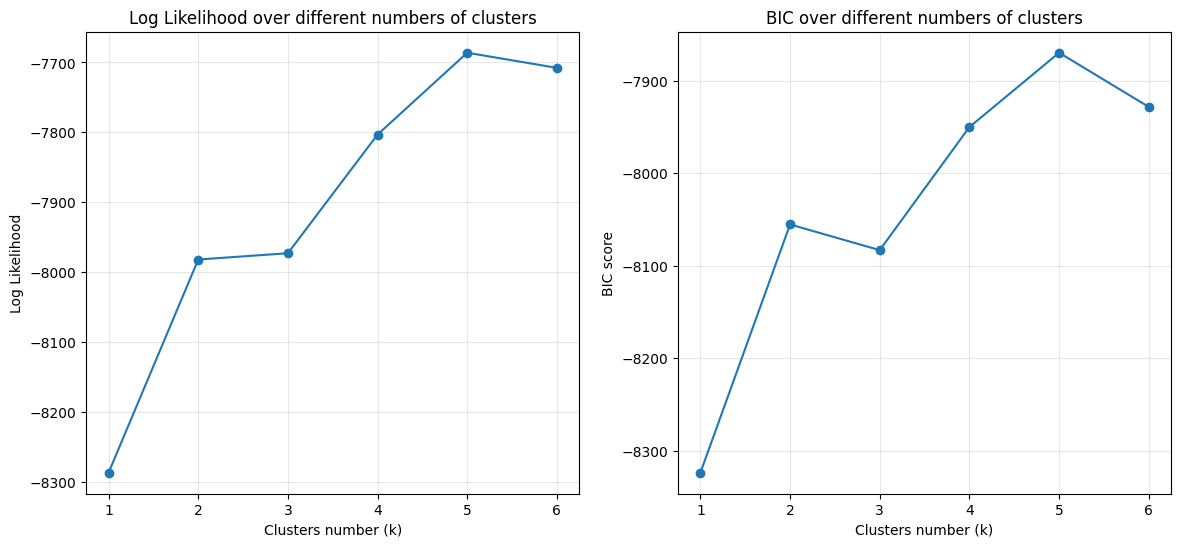

In [15]:
fig, (ax_ll, ax_bic) = plt.subplots(1, 2, figsize=(14, 6))
ax_ll.set_title("Log Likelihood over different numbers of clusters")
ax_ll.set_xlabel("Clusters number (k)")
ax_ll.set_ylabel("Log Likelihood")
ll_colors = ["orange"] * 6
ll_colors[np.argmax(lls)] = "blue"
ax_ll.grid(True, alpha=0.3)
ax_ll.plot([k for k in range(1, 7)], lls, marker="o")

ax_bic.set_title("BIC over different numbers of clusters")
ax_bic.set_xlabel("Clusters number (k)")
ax_bic.set_ylabel("BIC score")
bic_colors = ["orange"] * 6
bic_colors[np.argmax(bics)] = "blue"
ax_bic.grid(True, alpha=0.3)
ax_bic.plot([k for k in range(1, 7)], bics, marker="o")

### Conclusions
As we can clearly see, the model with $k=5$ is the best one, with the highest Log Likelihood and BIC.